# 🚀 3. Grayscale Average Pipeline — Training CNN, Ekstraksi Fitur & Training SVM
Notebook ini menjalankan pipeline lengkap untuk representasi **Grayscale Average** ($Gray = (R+G+B)/3$):
1. Konversi CIFAR-10 ke Grayscale Average `(32, 32, 1)` dan partisi data.
2. Training Custom Deep Residual CNN (input 1 kanal).
3. Ekstraksi fitur 512-D layer `svm_features` untuk train & test set.
4. Training SVM Classifier pada fitur Grayscale Average dan penyimpanan model final.

In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error alokasi
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D, Add, Activation
)
from tensorflow.keras.regularizers import l2

RANDOM_STATE = 23092026

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_data(load_train=True, load_test=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    if load_train:
        X_train = X_train.astype('float32') / 255.0
        y_train = y_train.flatten()
    else:
        X_train, y_train = None, None
    if load_test:
        X_test = X_test.astype('float32') / 255.0
        y_test = y_test.flatten()
    else:
        X_test, y_test = None, None
    return X_train, y_train, X_test, y_test

def transform_grayscale_avg(X):
    return np.mean(X, axis=-1, keepdims=True).astype('float32')

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False, dense_units=512, dropout_rate=0.25, weight_decay=1e-4):
    """
    Membangun arsitektur Deep Residual CNN Kustom 4-Blok dengan Spatial Context Preservation (8x8 GAP),
    GlobalAveragePooling2D 512 dimensi ('svm_features') dan Label Smoothing untuk Grayscale AVG.
    """
    inputs = Input(shape=input_shape, name='input_image')

    # BLOCK 1: 32x32 -> 16x16 (64 filters) dengan Residual Shortcut
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x1 = BatchNormalization(name='bn1_1')(x1)
    x1 = Activation('relu', name='relu1_1')(x1)
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_2')(x1)
    x1 = BatchNormalization(name='bn1_2')(x1)
    shortcut1 = Conv2D(64, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut1')(inputs)
    x1 = Add(name='add1')([x1, shortcut1])
    x1 = Activation('relu', name='relu1_2')(x1)
    x1 = MaxPooling2D((2, 2), name='pool1')(x1)  # 16x16
    x1 = Dropout(dropout_rate * 0.6, name='dropout1')(x1)

    # BLOCK 2: 16x16 -> 8x8 (128 filters) dengan Residual Shortcut
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_1')(x1)
    x2 = BatchNormalization(name='bn2_1')(x2)
    x2 = Activation('relu', name='relu2_1')(x2)
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_2')(x2)
    x2 = BatchNormalization(name='bn2_2')(x2)
    shortcut2 = Conv2D(128, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut2')(x1)
    x2 = Add(name='add2')([x2, shortcut2])
    x2 = Activation('relu', name='relu2_2')(x2)
    x2 = MaxPooling2D((2, 2), name='pool2')(x2)  # 8x8
    x2 = Dropout(dropout_rate, name='dropout2')(x2)

    # BLOCK 3: 8x8 -> 8x8 (256 filters) - Preservasi Resolusi Spasial 8x8
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_1')(x2)
    x3 = BatchNormalization(name='bn3_1')(x3)
    x3 = Activation('relu', name='relu3_1')(x3)
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_2')(x3)
    x3 = BatchNormalization(name='bn3_2')(x3)
    shortcut3 = Conv2D(256, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut3')(x2)
    x3 = Add(name='add3')([x3, shortcut3])
    x3 = Activation('relu', name='relu3_2')(x3)
    x3 = Dropout(dropout_rate * 1.2, name='dropout3')(x3)

    # BLOCK 4: 8x8 -> 8x8 (512 filters) - Deep High-Capacity Representation
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv4_1')(x3)
    x4 = BatchNormalization(name='bn4_1')(x4)
    x4 = Activation('relu', name='relu4_1')(x4)
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='feature_map')(x4)
    x4 = BatchNormalization(name='feature_map_bn')(x4)
    shortcut4 = Conv2D(512, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut4')(x3)
    x4 = Add(name='add4')([x4, shortcut4])
    x4 = Activation('relu', name='relu4_2')(x4)
    x4 = Dropout(dropout_rate * 1.4, name='dropout4')(x4)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    # GAP mengintegrasikan 8x8=64 posisi spasial beresolusi tinggi ke dalam representasi 512-dimensi
    svm_features = GlobalAveragePooling2D(name='svm_features')(x4)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.40, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='custom_cnn_avg')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model


Artifact directory: cifar10_artifacts/grayscale_avg
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 1. Memuat Data CIFAR-10, Transformasi Grayscale AVG & Partisi Data 3-Way Stratified (40k / 5k / 5k)
Data training dikonversi ke Grayscale AVG `(32, 32, 1)`, lalu dipartisi secara *stratified*:
- **40.000 CNN Training Data** (80%)
- **5.000 CNN Validation Data** (10%)
- **5.000 Independent SVM Validation Data** (10% - Unseen oleh CNN)
Data testing resmi (10.000 sampel) diisolasi mutlak untuk pengujian akhir.

Bentuk X_train_feat (AVG): (50000, 32, 32, 1)
=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. CNN Training Set            : (40000, 32, 32, 1) | 40000 sampel (80% - Pelatihan CNN)
2. CNN Validation Set          : (5000, 32, 32, 1)   | 5000 sampel (10% - Monitor Callbacks & Checkpoint)
3. Independent SVM Val Set     : (5000, 32, 32, 1)   | 5000 sampel (10% - Unseen by CNN, untuk Tuning SVM)
4. Official Test Set Murni     : (10000, 32, 32, 3)  | 10000 sampel (Terisolasi untuk Pengujian Akhir)


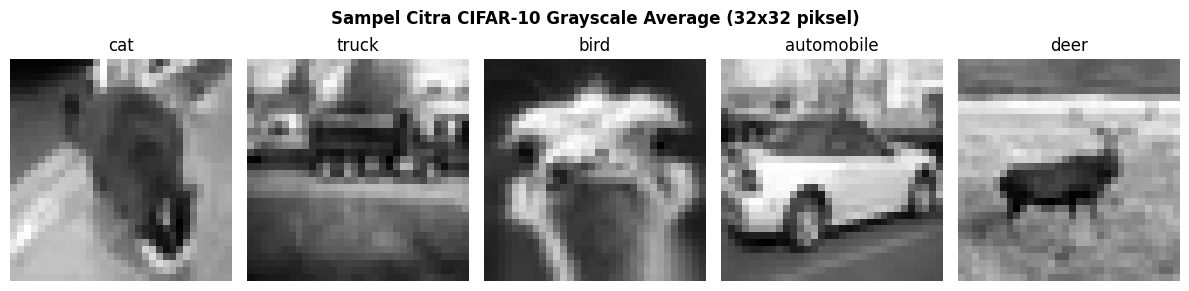

In [2]:
X_train_raw, y_train_raw, X_test, y_test = load_cifar10_data()

# Transformasi citra ke Grayscale Average (AVG) (32, 32, 1)
X_train_feat = transform_grayscale_avg(X_train_raw)
print(f"Bentuk X_train_feat (AVG): {X_train_feat.shape}")

# Definisi Partisi 3-Way Stratified Murni
def get_cifar10_partitions(y_train_labels):
    """
    Partisi 50.000 sampel CIFAR-10 secara stratified dan deterministik:
    - 40.000 CNN training
    -  5.000 CNN validation (monitor early stopping & checkpoint CNN)
    -  5.000 independent SVM validation (unseen oleh CNN, untuk tuning SVM)
    Zero overlap: CNN train ∩ CNN val = ∅, CNN train ∩ SVM val = ∅, CNN val ∩ SVM val = ∅
    """
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val

idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train_raw)

X_train = X_train_feat[idx_cnn_train]       # 40.000 sampel (CNN Training)
y_train = y_train_raw[idx_cnn_train]

X_val = X_train_feat[idx_cnn_val]           # 5.000 sampel (CNN Validation)
y_val = y_train_raw[idx_cnn_val]

X_svm_val = X_train_feat[idx_svm_val]       # 5.000 sampel (Independent SVM Val - Unseen by CNN!)
y_svm_val = y_train_raw[idx_svm_val]

y_train_cat   = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat     = tf.keras.utils.to_categorical(y_val, 10)
y_svm_val_cat = tf.keras.utils.to_categorical(y_svm_val, 10)
y_test_cat    = tf.keras.utils.to_categorical(y_test, 10)

print("=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. CNN Training Set            : {X_train.shape} | {len(X_train)} sampel (80% - Pelatihan CNN)")
print(f"2. CNN Validation Set          : {X_val.shape}   | {len(X_val)} sampel (10% - Monitor Callbacks & Checkpoint)")
print(f"3. Independent SVM Val Set     : {X_svm_val.shape}   | {len(X_svm_val)} sampel (10% - Unseen by CNN, untuk Tuning SVM)")
print(f"4. Official Test Set Murni     : {X_test.shape}  | {len(X_test)} sampel (Terisolasi untuk Pengujian Akhir)")

# Visualisasi sampel citra Grayscale AVG
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f"{CLASS_NAMES[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 Grayscale Average (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model CNN Kustom Grayscale (1 Channel)
Arsitektur 4-blok dengan layer ekstraksi `svm_features` (GlobalAveragePooling2D 512-dimensi) dan input shape `(32, 32, 1)`.


In [3]:
cnn_model = build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False)
cnn_model.summary()


Model: "custom_cnn_avg"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 32, 32, 1)]  0           []                               
                                                                                                  
 conv1_1 (Conv2D)               (None, 32, 32, 64)   640         ['input_image[0][0]']            
                                                                                                  
 bn1_1 (BatchNormalization)     (None, 32, 32, 64)   256         ['conv1_1[0][0]']                
                                                                                                  
 relu1_1 (Activation)           (None, 32, 32, 64)   0           ['bn1_1[0][0]']                  
                                                                                     

## ⚙️ 3. Training CNN dengan Data Augmentation & Cosine Decay Annealing (Target Optimal)

Melatih CNN Grayscale Average menggunakan konfigurasi optimal:
- **8x8 Spatial GAP**: Fitur representasi 512-D yang kaya konteks spasial.
- **Cosine Decay Learning Rate Annealing**: Menurunkan LR secara mulus dari `1e-3` ke `1e-5`.
- **Data Augmentation Anti-Blurring**: Translasi ±4 piksel (0.125) dan horizontal flip.
- **Callbacks**: `LearningRateScheduler` (Cosine Decay), `EarlyStopping`, dan `ModelCheckpoint`.


In [4]:
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

# Enhanced Data Augmentation terarah untuk citra 32x32 grayscale AVG (Anti-Blurring)
datagen = ImageDataGenerator(
    width_shift_range=0.125,
    height_shift_range=0.125,
    horizontal_flip=True,
    fill_mode='nearest'
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateScheduler
)

BATCH_SIZE = 64
EPOCHS = 100
train_flow = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True, seed=RANDOM_STATE)
steps_per_epoch = len(X_train) // BATCH_SIZE

cnn_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

def cosine_decay_schedule(epoch, lr):
    initial_lr = 1e-3
    min_lr = 1e-5
    return min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * epoch / EPOCHS))

callbacks = [
    LearningRateScheduler(cosine_decay_schedule, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=25, restore_best_weights=True, verbose=1),
    ModelCheckpoint(cnn_model_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

print("Memulai pelatihan CNN Grayscale Average (AVG) (8x8 Spatial GAP + Cosine Annealing)...\n")
history = cnn_model.fit(
    train_flow,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

# Memastikan memuat bobot terbaik yang tersimpan oleh ModelCheckpoint
if os.path.exists(cnn_model_path):
    cnn_model = tf.keras.models.load_model(cnn_model_path)
    print(f"[BERHASIL] Model CNN AVG dengan bobot checkpoint terbaik berhasil dimuat dari: {cnn_model_path}")
else:
    cnn_model.save(cnn_model_path)
    print(f"[BERHASIL] Model CNN AVG terbaik disimpan ke: {cnn_model_path}")

# Evaluasi akhir pada validation set
val_eval = cnn_model.evaluate(X_val, y_val_cat, verbose=0)
print(f"\nTuned Model AVG (Best Weights) -> Val Loss: {val_eval[0]:.4f}, Val Accuracy: {val_eval[1] * 100:.2f}%")


Memulai pelatihan CNN Grayscale Average (AVG) (8x8 Spatial GAP + Cosine Annealing)...


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100
625/625 [==============================] - ETA: 0s - loss: 2.1194 - accuracy: 0.3932 - precision: 0.5872 - recall: 0.1911
Epoch 1: val_accuracy improved from -inf to 0.38560, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
625/625 [==============================] - 50s 68ms/step - loss: 2.1194 - accuracy: 0.3932 - precision: 0.5872 - recall: 0.1911 - val_loss: 2.1756 - val_accuracy: 0.3856 - val_precision: 0.5739 - val_recall: 0.2026 - lr: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009997557473810372.
Epoch 2/100
625/625 [==============================] - ETA: 0s - loss: 1.6049 - accuracy: 0.5919 - precision: 0.7714 - recall: 0.4068
Epoch 2: val_accuracy improved from 0.38560 to 0.61660, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
625/625 [===========================

## 📈 4. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)
Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation.


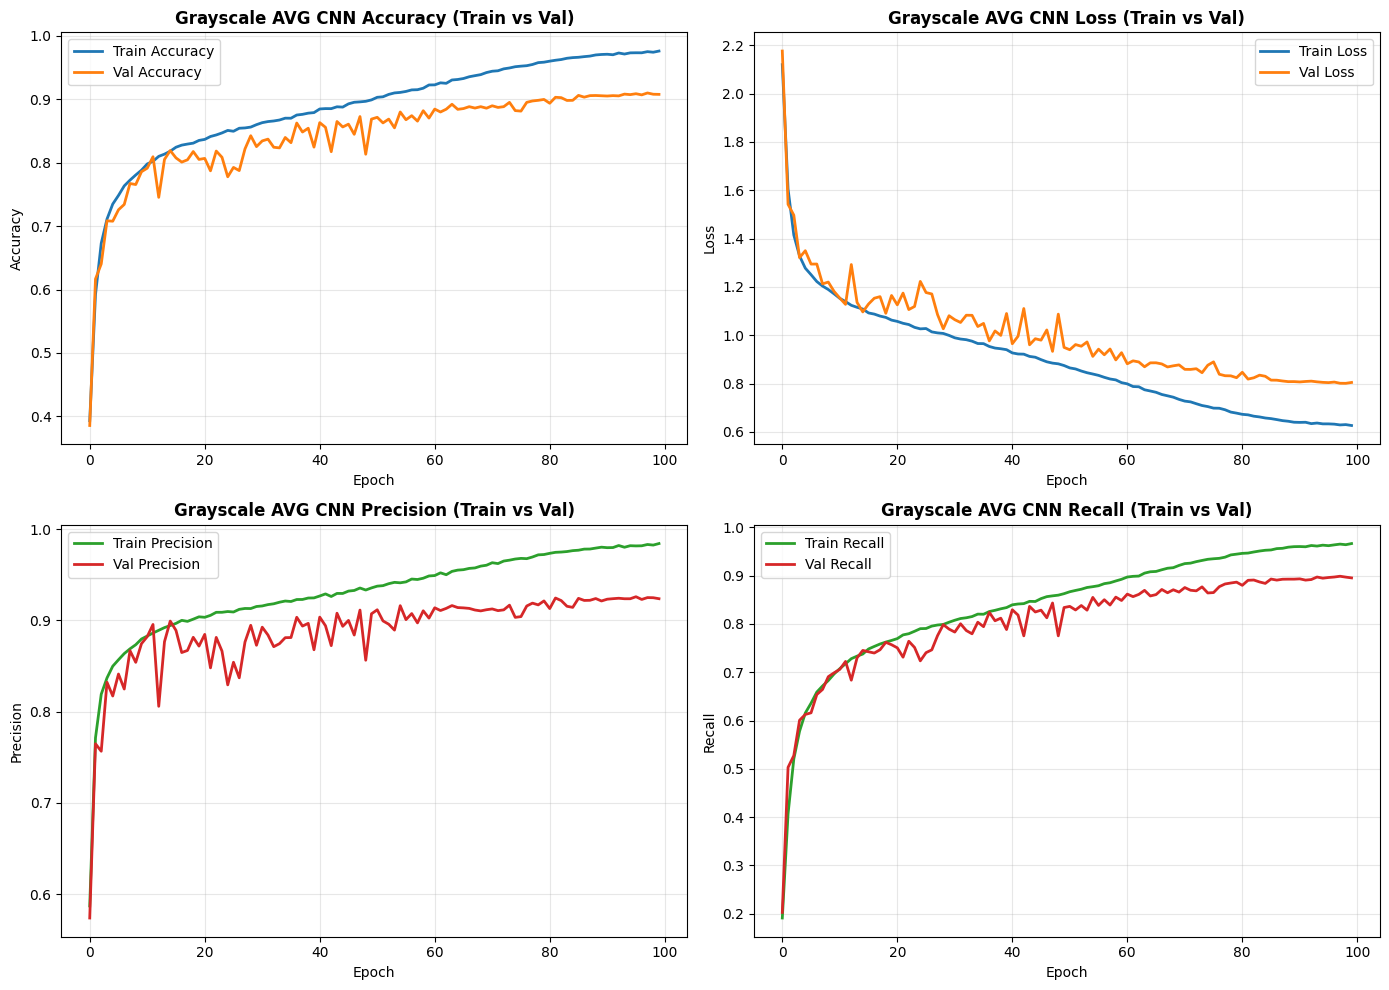

Kurva pelatihan tersimpan ke: cifar10_artifacts/grayscale_avg\learning_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('Grayscale AVG CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('Grayscale AVG CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('Grayscale AVG CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('Grayscale AVG CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")


---
## 🧠 5. Ekstraksi Vektor Fitur CNN Grayscale Average (512-dimensi)
Ekstraksi representasi fitur tingkat tinggi dari layer `svm_features`.

In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import numpy as np
import tensorflow as tf

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error 'DNN library is not found'
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass



ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')
print(f"Memuat model CNN AVG terlatih dari: {cnn_model_path}")
cnn_model = tf.keras.models.load_model(cnn_model_path)

from tensorflow.keras.models import Model

def load_cifar10_data(load_train=True, load_test=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    if load_train:
        X_train = X_train.astype('float32') / 255.0
        y_train = y_train.flatten()
    else:
        X_train, y_train = None, None
    if load_test:
        X_test = X_test.astype('float32') / 255.0
        y_test = y_test.flatten()
    else:
        X_test, y_test = None, None
    return X_train, y_train, X_test, y_test

def transform_grayscale_avg(X):
    return np.mean(X, axis=-1, keepdims=True).astype('float32')

def extract_cnn_features(model, X_data, batch_size=128, use_tta=True):
    feature_layer = model.get_layer('svm_features')
    extractor = tf.keras.models.Model(inputs=model.input, outputs=feature_layer.output)
    print(f"Feature Extractor Layer : {feature_layer.name} | Output Shape : {feature_layer.output_shape}")
    total_samples = len(X_data)
    features = []
    for i in range(0, total_samples, batch_size):
        end = min(i + batch_size, total_samples)
        batch = X_data[i:end]
        f1 = extractor.predict(batch, batch_size=batch_size, verbose=0)
        if use_tta:
            f2 = extractor.predict(np.flip(batch, axis=2), batch_size=batch_size, verbose=0)
            feats = 0.5 * (f1 + f2)
        else:
            feats = f1
        features.append(feats)
    features_arr = np.vstack(features)
    print(f"[EKSTRAKSI SELESAI] Extracted Features Shape: {features_arr.shape}")
    return features_arr

from sklearn.model_selection import train_test_split

RANDOM_STATE = 23092026

def get_cifar10_partitions(y_train_labels):
    """
    Partisi 50.000 sampel CIFAR-10 secara stratified dan deterministik:
    - 40.000 CNN training
    -  5.000 CNN validation (monitor early stopping & checkpoint CNN)
    -  5.000 independent SVM validation (unseen oleh CNN, untuk tuning SVM)
    Zero overlap: CNN train ∩ CNN val = ∅, CNN train ∩ SVM val = ∅, CNN val ∩ SVM val = ∅
    """
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val


Memuat model CNN AVG terlatih dari: cifar10_artifacts/grayscale_avg\cnn_model.keras


## 📥 1. Memuat Data & Mengekstrak Vektor Fitur CNN


In [2]:
X_train_raw, y_train, X_test_raw, y_test = load_cifar10_data()

# Transformasi ke Grayscale AVG
X_train = transform_grayscale_avg(X_train_raw)
X_test  = transform_grayscale_avg(X_test_raw)

print("Mengekstrak fitur CNN Grayscale Average (AVG) dari data training (50.000 sampel)... (TTA Horizontal Flip)")
X_train_features = extract_cnn_features(cnn_model, X_train, batch_size=128, use_tta=True)

print("\nMengekstrak fitur CNN Grayscale Average (AVG) dari data testing (10.000 sampel)... (TTA Horizontal Flip)")
X_test_features = extract_cnn_features(cnn_model, X_test, batch_size=128, use_tta=True)

# Hitung partisi indeks stratified deterministik
idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train)

print()
print(f"[SELESAI] X_train_features shape: {X_train_features.shape}")
print(f"[SELESAI] X_test_features shape : {X_test_features.shape}")
print(f"  - CNN Training Partition      : {len(idx_cnn_train)} sampel (40k)")
print(f"  - CNN Validation Partition    : {len(idx_cnn_val)} sampel (5k)")
print(f"  - Independent SVM Val Part.   : {len(idx_svm_val)} sampel (5k unseen oleh CNN)")


Mengekstrak fitur CNN Grayscale Average (AVG) dari data training (50.000 sampel)... (TTA Horizontal Flip)
Feature Extractor Layer : svm_features | Output Shape : (None, 512)
[EKSTRAKSI SELESAI] Extracted Features Shape: (50000, 512)

Mengekstrak fitur CNN Grayscale Average (AVG) dari data testing (10.000 sampel)... (TTA Horizontal Flip)
Feature Extractor Layer : svm_features | Output Shape : (None, 512)
[EKSTRAKSI SELESAI] Extracted Features Shape: (10000, 512)

[SELESAI] X_train_features shape: (50000, 512)
[SELESAI] X_test_features shape : (10000, 512)
  - CNN Training Partition      : 40000 sampel (40k)
  - CNN Validation Partition    : 5000 sampel (5k)
  - Independent SVM Val Part.   : 5000 sampel (5k unseen oleh CNN)


## 💾 2. Menyimpan Vektor Fitur ke Disk (.npz)


In [3]:
train_feat_path = os.path.join(ARTIFACT_DIR, 'train_features.npz')
test_feat_path  = os.path.join(ARTIFACT_DIR, 'test_features.npz')

# Simpan murni fitur dan partisi indeks (tanpa prediction cache)
np.savez_compressed(
    train_feat_path,
    X_train_features=X_train_features,
    y_train=y_train,
    idx_cnn_train=idx_cnn_train,
    idx_cnn_val=idx_cnn_val,
    idx_svm_val=idx_svm_val
)
np.savez_compressed(test_feat_path, X_test_features=X_test_features, y_test=y_test)

print(f"[BERHASIL] Fitur training Grayscale Average (AVG) tersimpan: {train_feat_path}")
print(f"[BERHASIL] Fitur testing Grayscale Average (AVG) tersimpan : {test_feat_path}")


[BERHASIL] Fitur training Grayscale Average (AVG) tersimpan: cifar10_artifacts/grayscale_avg\train_features.npz
[BERHASIL] Fitur testing Grayscale Average (AVG) tersimpan : cifar10_artifacts/grayscale_avg\test_features.npz


---
## ⚔️ 6. Pelatihan SVM Classifier Grayscale Average & Serialisasi Final
Standarisasi fitur training dan pelatihan model SVM RBF.

In [1]:
import os
import sys
import h5py
import pickle
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
train_feat_path = os.path.join(ARTIFACT_DIR, 'train_features.npz')
print(f"Memuat vektor fitur training dari: {train_feat_path}")
train_data = np.load(train_feat_path)
X_train_features = train_data['X_train_features']
y_train = train_data['y_train']

RANDOM_STATE = 23092026

def save_and_inject_final_model(cnn_model, scaler, svm_model, artifact_path, metadata=None):
    os.makedirs(os.path.dirname(artifact_path), exist_ok=True)
    cnn_model.save(artifact_path)
    scaler_bytes = pickle.dumps(scaler, protocol=pickle.HIGHEST_PROTOCOL)
    svm_bytes = pickle.dumps(svm_model, protocol=pickle.HIGHEST_PROTOCOL)
    with h5py.File(artifact_path, 'a') as h5f:
        if 'scaler_pickle' in h5f:
            del h5f['scaler_pickle']
        if 'svm_model_pickle' in h5f:
            del h5f['svm_model_pickle']
        if 'svm_pipeline_pickle' in h5f:
            del h5f['svm_pipeline_pickle']
        h5f.create_dataset('scaler_pickle', data=np.frombuffer(scaler_bytes, dtype=np.uint8), compression='gzip')
        h5f.create_dataset('svm_model_pickle', data=np.frombuffer(svm_bytes, dtype=np.uint8), compression='gzip')
        if metadata:
            for k, v in metadata.items():
                if isinstance(v, (int, float, str)):
                    h5f.attrs[k] = v
                else:
                    h5f.attrs[k] = str(v)
    print(f"[BERHASIL] Seluruh model (CNN + Scaler + SVM) tersimpan dalam SATU file (.keras): {artifact_path}")

def load_injected_final_model(artifact_path):
    if not os.path.exists(artifact_path):
        raise FileNotFoundError(f"File model {artifact_path} tidak ditemukan!")
    cnn_model = tf.keras.models.load_model(artifact_path)
    with h5py.File(artifact_path, 'r') as h5f:
        if 'scaler_pickle' in h5f and 'svm_model_pickle' in h5f:
            scaler_bytes = bytes(h5f['scaler_pickle'][()])
            svm_bytes = bytes(h5f['svm_model_pickle'][()])
            scaler = pickle.loads(scaler_bytes)
            svm_model = pickle.loads(svm_bytes)
        elif 'svm_pipeline_pickle' in h5f:
            pipe_bytes = bytes(h5f['svm_pipeline_pickle'][()])
            pipe_obj = pickle.loads(pipe_bytes)
            if hasattr(pipe_obj, 'named_steps'):
                scaler = pipe_obj.named_steps.get('scaler', None)
                svm_model = pipe_obj.named_steps.get('svm', pipe_obj)
            else:
                scaler = None
                svm_model = pipe_obj
        else:
            raise KeyError(f"Dataset Scaler/SVM tidak ditemukan dalam {artifact_path}!")
        metadata = {}
        for k, v in h5f.attrs.items():
            if isinstance(v, bytes):
                metadata[k] = v.decode('utf-8')
            else:
                metadata[k] = v
    return cnn_model, scaler, svm_model, metadata


Memuat vektor fitur training dari: cifar10_artifacts/grayscale_avg\train_features.npz


## 🛠️ 1. Validation-Driven Tuning & Pelatihan Model SVM Classifier (Zero Leakage)


In [2]:
# 1. Partisi 50.000 sampel CIFAR-10 secara deterministik & stratified (Zero Leakage)
def get_cifar10_partitions(y_train_labels):
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val

if 'idx_cnn_train' in train_data and 'idx_svm_val' in train_data:
    idx_cnn_train = train_data['idx_cnn_train']
    idx_svm_val = train_data['idx_svm_val']
else:
    idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train)

# Verifikasi matematis zero overlap antar partisi
assert len(set(idx_cnn_train).intersection(set(idx_svm_val))) == 0, "Data leakage detected between CNN train and SVM val!"

# Subset untuk validation-driven hyperparameter tuning
# SVM-train: 40.000 sampel (fitur dari partisi training CNN)
# SVM-val  :  5.000 sampel (fitur unseen oleh CNN, murni untuk validasi SVM)
X_tr_sub, y_tr_sub = X_train_features[idx_cnn_train], y_train[idx_cnn_train]
X_va_sub, y_va_sub = X_train_features[idx_svm_val], y_train[idx_svm_val]

print("Partisi Data Training SVM:")
print(f"  - SVM Sub-Train (fitur CNN-train): {X_tr_sub.shape} ({len(y_tr_sub)} sampel)")
print(f"  - Independent SVM Val            : {X_va_sub.shape} ({len(y_va_sub)} sampel, unseen oleh CNN)\n")

# Optimasi Akselerasi: Menggunakan subset representatif stratified (10.000 sampel) untuk pencarian grid
# Kompleksitas SVM O(N^2): 10k sampel adalah ~16x lebih cepat dibanding 40k sampel dengan estimasi parameter optimal yang konsisten.
TUNE_SAMPLE_SIZE = 10000
if len(X_tr_sub) > TUNE_SAMPLE_SIZE:
    idx_tune, _ = train_test_split(
        np.arange(len(X_tr_sub)),
        train_size=TUNE_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_tr_sub
    )
    X_tr_tune, y_tr_tune = X_tr_sub[idx_tune], y_tr_sub[idx_tune]
    print(f"[AKSELERASI] Menggunakan subset representatif stratified {len(X_tr_tune)} sampel untuk pencarian parameter.")
else:
    X_tr_tune, y_tr_tune = X_tr_sub, y_tr_sub

# Standarisasi fitur: Fit HANYA pada data tuning sub-train, transform pada validation (Strict Zero Leakage)
sub_scaler = StandardScaler()
X_tr_tune_scaled = sub_scaler.fit_transform(X_tr_tune)
X_va_sub_scaled = sub_scaler.transform(X_va_sub)

gamma_scale = 1.0 / (X_tr_tune_scaled.shape[1] * X_tr_tune_scaled.var())
print(f"Nilai dasar gamma ('scale') pada data tuning: {gamma_scale:.6f}\n")

# Kandidat Hyperparameter Sesuai Spesifikasi Akademik
C_CANDIDATES = [1, 3, 5, 8, 10, 15, 20, 25, 30]
GAMMA_MULTIPLIERS = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
KERNEL = 'rbf'

print("=" * 72)
print("  VALIDATION-DRIVEN HYPERPARAMETER SEARCH (MULTI-CORE CPU ACCELERATED)")
print("=" * 72)

def eval_svm_candidate(c_cand, g_mult):
    gamma_val = g_mult * gamma_scale
    cand_svc = SVC(
        C=float(c_cand),
        gamma=gamma_val,
        kernel=KERNEL,
        cache_size=1024,
        random_state=RANDOM_STATE
    )
    cand_svc.fit(X_tr_tune_scaled, y_tr_tune)
    val_acc = cand_svc.score(X_va_sub_scaled, y_va_sub)
    return {
        'C': float(c_cand),
        'gamma_mult': g_mult,
        'gamma': gamma_val,
        'val_acc': val_acc
    }

candidate_tasks = [(c, g) for c in C_CANDIDATES for g in GAMMA_MULTIPLIERS]
print(f"Mengevaluasi {len(candidate_tasks)} kombinasi parameter secara paralel memanfaatkan seluruh CPU core...")
results = Parallel(n_jobs=-1, batch_size=2)(
    delayed(eval_svm_candidate)(c, g) for c, g in candidate_tasks
)

best_result = max(results, key=lambda x: x['val_acc'])
for res in sorted(results, key=lambda x: (x['C'], x['gamma_mult'])):
    print(f"C={res['C']:4.1f} | gamma={res['gamma_mult']:4.2f}x ({res['gamma']:.6f}) -> Val Acc: {res['val_acc']*100:.2f}%")

print("-" * 72)
print(f"[HASIL TUNING] Konfigurasi terbaik terpilih murni dari Independent SVM Validation Set:")
print(f"  C: {best_result['C']}, Gamma Multiplier: {best_result['gamma_mult']}x (gamma: {best_result['gamma']:.6f})")
print(f"  Validation Accuracy: {best_result['val_acc'] * 100:.2f}%\n")

SVM_C = best_result['C']
SVM_GAMMA = best_result['gamma']

# Refit final SVM pada seluruh 50.000 sampel training menggunakan konfigurasi terbaik
print(f"2. Melatih Model Final SVM pada seluruh 50.000 sampel training (C={SVM_C}, gamma={SVM_GAMMA:.6f})...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

svm_model = SVC(
    C=SVM_C,
    gamma=SVM_GAMMA,
    kernel=KERNEL,
    cache_size=4096,
    random_state=RANDOM_STATE,
    decision_function_shape='ovr'
)
svm_model.fit(X_train_scaled, y_train)
print("[BERHASIL] Model SVM Final telah selesai dilatih pada seluruh 50.000 sampel!")

sample_acc = accuracy_score(y_train[:5000], svm_model.predict(X_train_scaled[:5000]))
print(f"Akurasi SVM pada sampel training: {sample_acc * 100:.2f}%")


Partisi Data Training SVM:
  - SVM Sub-Train (fitur CNN-train): (40000, 512) (40000 sampel)
  - Independent SVM Val            : (5000, 512) (5000 sampel, unseen oleh CNN)

[AKSELERASI] Menggunakan subset representatif stratified 10000 sampel untuk pencarian parameter.
Nilai dasar gamma ('scale') pada data tuning: 0.007299

  VALIDATION-DRIVEN HYPERPARAMETER SEARCH (MULTI-CORE CPU ACCELERATED)
Mengevaluasi 54 kombinasi parameter secara paralel memanfaatkan seluruh CPU core...
C= 1.0 | gamma=0.50x (0.003650) -> Val Acc: 90.92%
C= 1.0 | gamma=0.75x (0.005474) -> Val Acc: 90.94%
C= 1.0 | gamma=1.00x (0.007299) -> Val Acc: 90.88%
C= 1.0 | gamma=1.25x (0.009124) -> Val Acc: 90.88%
C= 1.0 | gamma=1.50x (0.010949) -> Val Acc: 90.82%
C= 1.0 | gamma=2.00x (0.014599) -> Val Acc: 90.78%
C= 3.0 | gamma=0.50x (0.003650) -> Val Acc: 90.88%
C= 3.0 | gamma=0.75x (0.005474) -> Val Acc: 90.90%
C= 3.0 | gamma=1.00x (0.007299) -> Val Acc: 90.98%
C= 3.0 | gamma=1.25x (0.009124) -> Val Acc: 91.02%
C= 3.0 | 

## 📦 2. Menyimpan Scaler & Model SVM ke File Model .keras Tunggal


In [3]:
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')
cnn_model = tf.keras.models.load_model(cnn_model_path)
final_keras_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')

# 1. Simpan standalone scaler.pkl dan svm_model.pkl untuk kepastian kompatibilitas
scaler_pkl_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_pkl_path = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')
with open(scaler_pkl_path, 'wb') as f:
    pickle.dump(scaler, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(svm_pkl_path, 'wb') as f:
    pickle.dump(svm_model, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"[BERHASIL] Scaler dan SVM Model disimpan ke standalone .pkl: {scaler_pkl_path} & {svm_pkl_path}")

# 2. Simpan dan injeksikan ke file .keras tunggal
metadata = {
    'method': 'Grayscale Average (AVG) CNN + SVM',
    'feature': 'Grayscale AVG',
    'svm_C': float(SVM_C),
    'svm_gamma': str(SVM_GAMMA),
    'feature_dim': int(X_train_features.shape[1])
}

save_and_inject_final_model(cnn_model, scaler, svm_model, final_keras_path, metadata)

v_cnn, v_scaler, v_svm, v_meta = load_injected_final_model(final_keras_path)
print(f"[VERIFIKASI] Model final .keras berhasil memuat CNN ({v_cnn.name}), Scaler ({v_scaler}), dan SVM ({v_svm})!")


[BERHASIL] Scaler dan SVM Model disimpan ke standalone .pkl: cifar10_artifacts/grayscale_avg\scaler.pkl & cifar10_artifacts/grayscale_avg\svm_model.pkl
[BERHASIL] Seluruh model (CNN + Scaler + SVM) tersimpan dalam SATU file (.keras): cifar10_artifacts/grayscale_avg\custom_cnn_cifar10_final.keras
[VERIFIKASI] Model final .keras berhasil memuat CNN (custom_cnn_avg), Scaler (StandardScaler()), dan SVM (SVC(C=3.0, cache_size=4096, gamma=0.009124086575018158, random_state=23092026))!
